In [1]:
# ----------------------------------------------------------
# Book 3: Hybrid Model (TF-IDF + SBERT)
# ----------------------------------------------------------

# 1️⃣ Libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

print("Libraries imported successfully!")

✅ Libraries imported successfully!


In [7]:
import pandas as pd

df = pd.read_csv(r"C:\laragon\www\web\lokalkita\data\cleaned_metadata_2.csv")
print("Data loaded:", df.shape)
df.head(3)


✅ Data loaded: (226, 25)


,item_id,title,description,tags,category,location,state,min price (RM),max price (RM),operating hours,...,contact,more_info,opening_time,closing_time,price_type,clean_description,clean_tags,clean_category,clean_features,weighted_features
0,1,Ilham Ceramic Studio,"Ilham Seramik Studio showcases ceramic-making,...","ceramic, pottery, craft",Arts & Crafts,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,8.0,518.0,9:00 AM - 5:00 PM,...,013-599 4022,https://www.instagram.com/ilham_ceramic/?hl=en,9:00:00,17:00:00,Paid,ilham seramik studio showcase ceramicmaking cl...,ceramic pottery craft,art craft,ilham seramik studio showcase ceramicmaking cl...,Ilham Ceramic Studio Ilham Seramik Studio show...
1,2,Maklang Cafe By Ilham Ceramic Studio,Maklang Cafe by Ilham Ceramic offers cultural ...,"food, culinary, culture",Food & Culinary,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,0.5,15.0,8:00 AM - 6:00 PM,...,013-599 4022,https://naturallylangkawi.my/portfolio/ilham-s...,8:00:00,18:00:00,Paid,maklang cafe ilham ceramic offer cultural cuis...,food culinary culture,food culinary,maklang cafe ilham ceramic offer cultural cuis...,Maklang Cafe By Ilham Ceramic Studio Maklang C...
2,3,Perencah Mee Bandung Mak Pon,Perencah Mee Bandung Mak Pon offers varieties ...,"food, paste, culinary",Food & Culinary,"1, 2 & 3, Jalan Lembah Padang, Taman Lembah Pa...",Johor,12.0,30.0,10:00 AM - 7:00 PM,...,012-262 0044,https://shopee.com.my/Pes-Mee-Bandung-Muar-Mi-...,10:00:00,19:00:00,Paid,perencah mee bandung mak pon offer variety pas...,food paste culinary,food culinary,perencah mee bandung mak pon offer variety pas...,Perencah Mee Bandung Mak Pon Perencah Mee Band...


In [9]:
df['clean_features'] = (
    df['clean_description'] + ' ' +
    (df['clean_tags'] + ' ') * 3 +
    (df['clean_category'] + ' ') * 2
)


In [11]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(df['clean_features'])
tfidf_matrix = normalize(tfidf_matrix)
print("✅ TF-IDF matrix:", tfidf_matrix.shape)


✅ TF-IDF matrix: (226, 819)


In [13]:
# Load pre-trained SBERT model
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')
sbert_embeddings = model.encode(df['clean_features'], show_progress_bar=True)
print("✅ SBERT embeddings shape:", sbert_embeddings.shape)


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

✅ SBERT embeddings shape: (226, 384)


In [17]:
from sklearn.decomposition import PCA

common_dim = min(227, tfidf_matrix.shape[1], sbert_embeddings.shape[1], 226)

pca_tfidf = PCA(n_components=common_dim)
tfidf_reduced = pca_tfidf.fit_transform(tfidf_matrix.toarray())
print(f"TF-IDF retained variance: {pca_tfidf.explained_variance_ratio_.sum():.2%}")

pca_sbert = PCA(n_components=common_dim)
sbert_reduced = pca_sbert.fit_transform(sbert_embeddings)
print(f"SBERT retained variance: {pca_sbert.explained_variance_ratio_.sum():.2%}")


TF-IDF retained variance: 100.00%
SBERT retained variance: 100.00%


In [27]:
from sklearn.preprocessing import normalize, MinMaxScaler

# Normalize each
tfidf_norm = normalize(tfidf_reduced)
sbert_norm = normalize(sbert_reduced)

# Scale both to 0–1 range
scaler = MinMaxScaler()
tfidf_scaled = scaler.fit_transform(tfidf_norm)
sbert_scaled = scaler.fit_transform(sbert_norm)

# Combine equally
alpha, beta = 0.5, 0.5
hybrid_embeddings = (alpha * tfidf_scaled) + (beta * sbert_scaled)
hybrid_embeddings = normalize(hybrid_embeddings)

print("✅ Hybrid embedding shape:", hybrid_embeddings.shape)


✅ Hybrid embedding shape: (226, 226)


In [43]:
# --- Hybrid Option 1: Concatenation-based Fusion ---
from sklearn.preprocessing import normalize
import numpy as np

# Make sure both reduced vectors have the same number of rows
print("TF-IDF reduced shape:", tfidf_reduced.shape)
print("SBERT reduced shape:", sbert_reduced.shape)

# Concatenate along feature axis
hybrid_embeddings = np.concatenate([tfidf_reduced, sbert_reduced], axis=1)

# Normalize to unit length so cosine similarity behaves correctly
hybrid_embeddings = normalize(hybrid_embeddings)

print("✅ Hybrid embedding shape:", hybrid_embeddings.shape)


TF-IDF reduced shape: (226, 226)
SBERT reduced shape: (226, 226)
✅ Hybrid embedding shape: (226, 452)


In [45]:
# similarity metrics
from sklearn.metrics.pairwise import cosine_similarity

sim_tfidf = cosine_similarity(tfidf_matrix)
sim_sbert = cosine_similarity(sbert_embeddings)
sim_hybrid = cosine_similarity(hybrid_embeddings)

print("✅ Cosine similarity shapes:", sim_tfidf.shape, sim_sbert.shape, sim_hybrid.shape)
print({
    "TF-IDF": sim_tfidf.mean(),
    "SBERT": sim_sbert.mean(),
    "Hybrid": sim_hybrid.mean()
})


✅ Cosine similarity shapes: (226, 226) (226, 226) (226, 226)
{'TF-IDF': np.float64(0.05996245884251835), 'SBERT': np.float32(0.3485299), 'Hybrid': np.float64(3.336105509585904e-05)}


In [49]:
# Model-level hybrid: weighted combination of similarity matrices
sim_ensemble = 0.3 * sim_tfidf + 0.7 * sim_sbert

print("Average ensemble similarity:", sim_ensemble.mean())


Average ensemble similarity: 0.26195967248948504


In [51]:
#top hybrid recommendations
def get_hybrid_recommendations(item_name, df, cosine_sim, top_n=5):
    idx = df.index[df['title'].str.lower() == item_name.lower()].tolist()
    if not idx:
        print("Item not found.")
        return
    idx = idx[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    sim_indices = [i[0] for i in sim_scores]
    results = df[['title', 'category', 'state']].iloc[sim_indices]
    results['similarity'] = [i[1] for i in sim_scores]
    return results


example = get_hybrid_recommendations("Natural Batik Village", df, sim_hybrid)
print(f"\n🎯 Top recommendations for '{example}':\n")




🎯 Top recommendations for '                                                 title       category  \
212                           Maskamal Batik & Trading  Arts & Crafts   
31                                 Mybatik Art Gallery  Arts & Crafts   
77   Batik Wau Bulan (A Malaysian Heritage Kite) Ma...  Arts & Crafts   
34                               Nordin Batik Sdn. Bhd  Arts & Crafts   
30                                Cwoks Batik Workshop  Arts & Crafts   

            state  similarity  
212      Kelantan    0.400729  
31       Selangor    0.390583  
77         Melaka    0.385589  
34       Kelantan    0.365282  
30   Kuala Lumpur    0.364425  ':



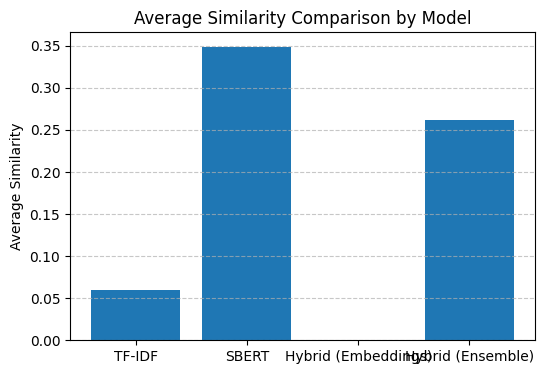

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Average similarity comparison
avg_scores = {
    "TF-IDF": sim_tfidf.mean(),
    "SBERT": sim_sbert.mean(),
    "Hybrid (Embeddings)": sim_hybrid.mean(),
    "Hybrid (Ensemble)": sim_ensemble.mean()
}

plt.figure(figsize=(6,4))
plt.bar(avg_scores.keys(), avg_scores.values())
plt.title("Average Similarity Comparison by Model")
plt.ylabel("Average Similarity")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


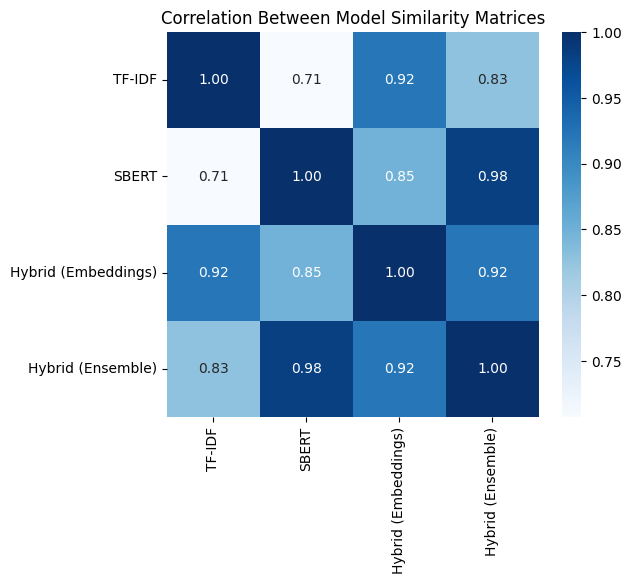

In [57]:
# 2. Correlation heatmap between models
data = {
    "TF-IDF": sim_tfidf.flatten(),
    "SBERT": sim_sbert.flatten(),
    "Hybrid (Embeddings)": sim_hybrid.flatten(),
    "Hybrid (Ensemble)": sim_ensemble.flatten()
}
corr_df = pd.DataFrame(data).corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Model Similarity Matrices")
plt.show()

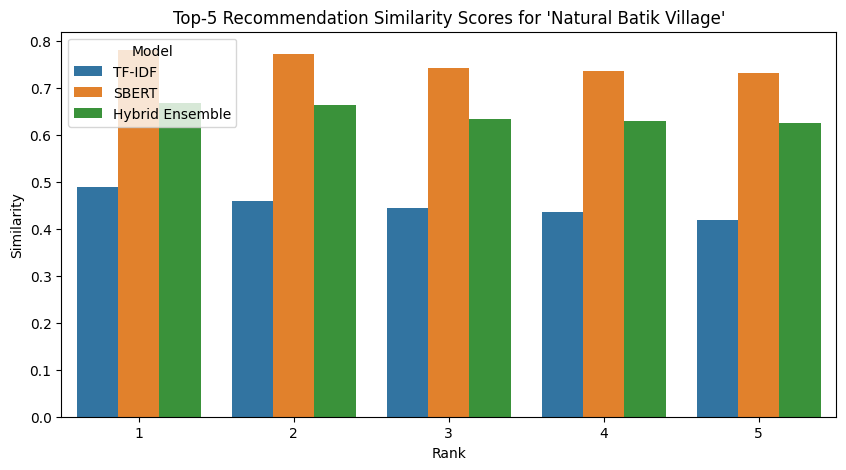

,Model,Rank,Title,Similarity
0,TF-IDF,1,Batik Wau Bulan (A Malaysian Heritage Kite) Ma...,0.488689
1,TF-IDF,2,Maskamal Batik & Trading,0.458636
2,TF-IDF,3,Kt Kraf,0.445530
3,TF-IDF,4,Lambo Sari,0.436911
4,TF-IDF,5,Mybatik Art Gallery,0.418956
0,SBERT,1,Cwoks Batik Workshop,0.780889
1,SBERT,2,Mybatik Art Gallery,0.773472
2,SBERT,3,Pusat Pengembangan Tenun Pahang Diraja Kg. Soi,0.741777
3,SBERT,4,Batik House My,0.735860
4,SBERT,5,Nordin Batik Sdn. Bhd,0.731404


In [63]:
# 3️. Top-k comparison visualization for one item
item_idx = df[df['title'].str.contains("Natural Batik Village", case=False, na=False)].index[0]

k = 5

def top_k_titles(sim_matrix, model_name):
    top_indices = sim_matrix[item_idx].argsort()[::-1][1:k+1]
    return pd.DataFrame({
        "Model": [model_name]*k,
        "Rank": np.arange(1, k+1),
        "Title": df.iloc[top_indices]['title'].values,
        "Similarity": sim_matrix[item_idx][top_indices]
    })
compare_df = pd.concat([
    top_k_titles(sim_tfidf, "TF-IDF"),
    top_k_titles(sim_sbert, "SBERT"),
    top_k_titles(sim_ensemble, "Hybrid Ensemble")
])

plt.figure(figsize=(10,5))
sns.barplot(data=compare_df, x="Rank", y="Similarity", hue="Model")
plt.title(f"Top-{k} Recommendation Similarity Scores for '{df.iloc[item_idx]['title']}'")
plt.show()

compare_df